In [125]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [126]:
df_init = pd.read_csv(r"insurance.csv")
df = df_init.copy()

EDA

In [127]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [128]:
df.shape

(1338, 7)

In [129]:
df = df.drop_duplicates()

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [131]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


<Axes: xlabel='age', ylabel='Count'>

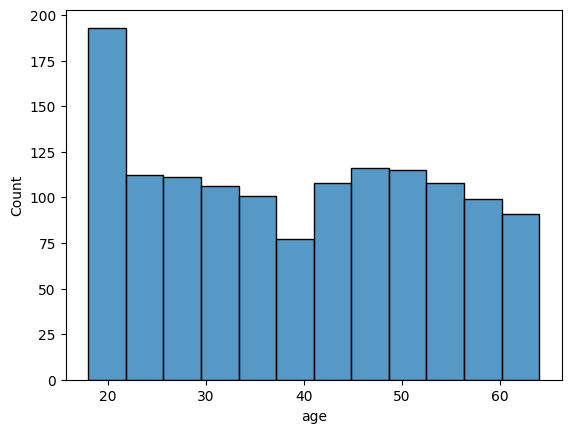

In [132]:
sns.histplot(x= df["age"])

<Axes: xlabel='sex', ylabel='count'>

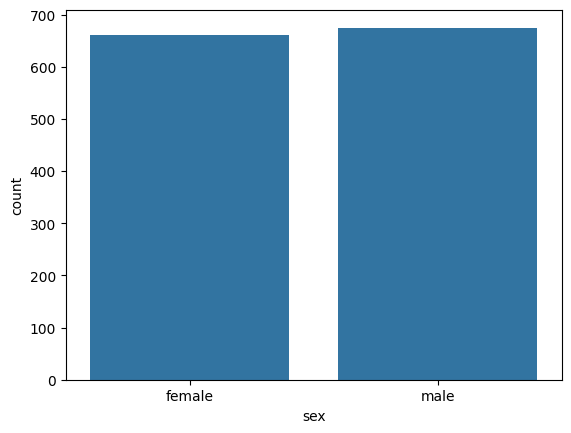

In [133]:
sns.countplot(x= df["sex"])

<Axes: xlabel='bmi', ylabel='Count'>

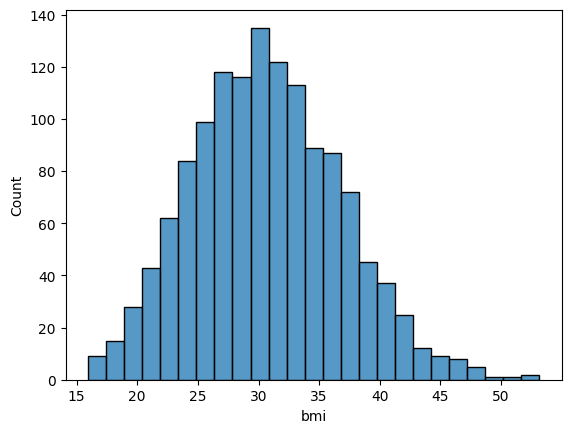

In [134]:
sns.histplot(df["bmi"])

<Axes: xlabel='children', ylabel='count'>

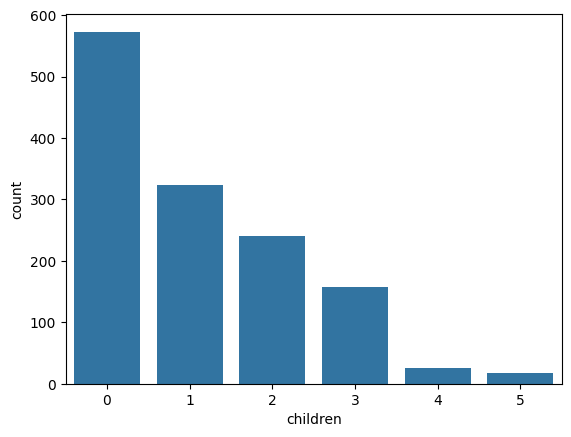

In [135]:
sns.countplot(x= df["children"])

<Axes: xlabel='smoker', ylabel='count'>

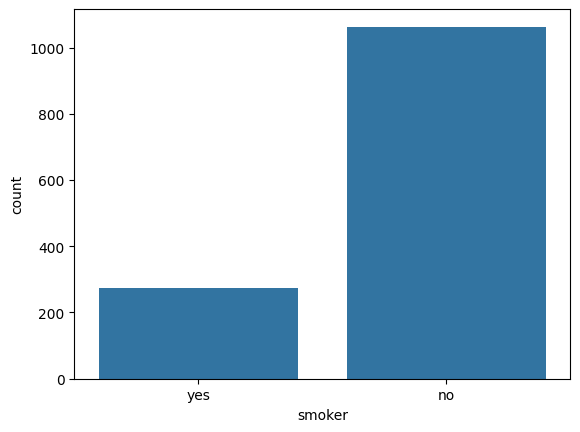

In [136]:
sns.countplot(x= df["smoker"])

<Axes: xlabel='count', ylabel='region'>

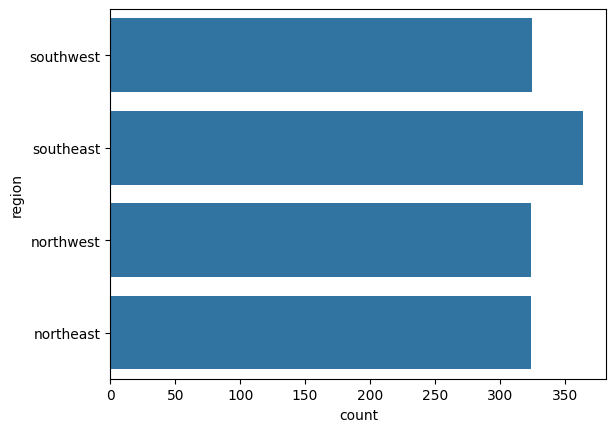

In [137]:
sns.countplot(df["region"])

<Axes: xlabel='charges', ylabel='Count'>

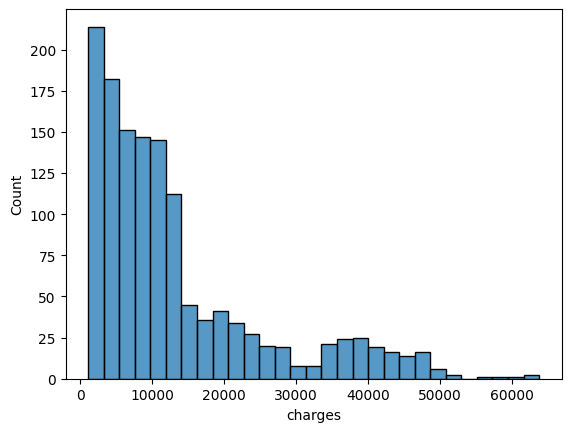

In [138]:
sns.histplot(df["charges"])

<Axes: >

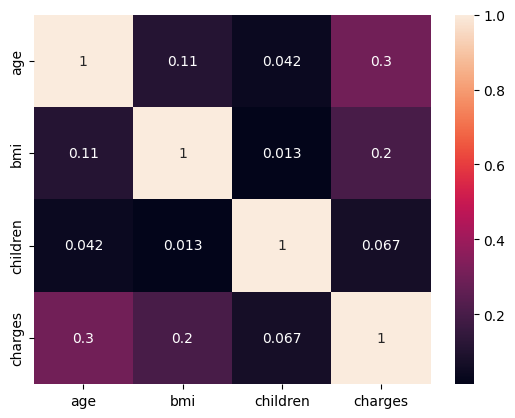

In [139]:
sns.heatmap(df.corr(numeric_only= True), annot= True)

Label Encoding

In [140]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [141]:
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})

In [142]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [143]:
df.rename(columns= {
    "sex": "is_female",
    "smoker": "is_smoker"
}, inplace= True)

Feature Extraction and Engineering

In [144]:
df = pd.get_dummies(df, columns= ["region"])

In [145]:
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [146]:
df = df.astype("int")

In [147]:
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


In [148]:
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins= [0, 18.5, 24.9, 29.9, float("inf")],
    labels= ["underweight", "normal", "overweight", "obese"]
)

In [149]:
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,overweight
1,18,0,33,1,0,1725,0,0,1,0,obese
2,28,0,33,3,0,4449,0,0,1,0,obese
3,33,0,22,0,0,21984,0,1,0,0,normal
4,32,0,28,0,0,3866,0,1,0,0,overweight


In [150]:
df = pd.get_dummies(df, columns= ["bmi_category"])

In [151]:
df = df.astype("int")
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


Standardization

In [152]:
from sklearn.preprocessing import StandardScaler

cols = ["age", "bmi", "children"]
scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

In [153]:
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0


Pearson Correlation

In [154]:
correlation_with_charges = df.corr(method='pearson')['charges'].drop('charges')

# Convert to a DataFrame with better formatting
correlation_df = pd.DataFrame({
    'Variable': correlation_with_charges.index,
    'Correlation_with_Charges': correlation_with_charges.values
})

# Sort by absolute correlation value (optional, to see strongest correlations first)
correlation_df['Abs_Correlation'] = correlation_df['Correlation_with_Charges'].abs()
correlation_df = correlation_df.sort_values('Abs_Correlation', ascending=False).drop('Abs_Correlation', axis=1)

# Reset index for cleaner look
correlation_df = correlation_df.reset_index(drop=True)

correlation_df

,Variable,Correlation_with_Charges
0,is_smoker,0.787234
1,age,0.298309
2,bmi_category_obese,0.200348
3,bmi,0.196236
4,bmi_category_overweight,-0.120601
5,bmi_category_normal,-0.104042
6,region_southeast,0.073577
7,children,0.067390
8,is_female,-0.058046
9,bmi_category_underweight,-0.050599


Chi square test

In [155]:
from scipy.stats import chi2_contingency
alpha = 0.05

In [156]:
cat_features = ["is_female", "is_smoker", "region_northeast", "region_northwest", "region_southeast", "region_southwest",
'bmi_category_underweight', 'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese']

In [157]:
df["charges_bin"] = pd.qcut(df["charges"], q= 4, labels= False)

In [158]:
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese,charges_bin
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0,3
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1,0
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0,3
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0,0


In [159]:
con = []

for col in cat_features:
    contingency = pd.crosstab(df[col], df["charges_bin"])
    chi, p_value, _, _, = chi2_contingency(contingency)
    decision = "keep feature" if p_value < alpha else "drop feature"
    con.append(col)
    con.append(decision)
    con.append(p_value)

In [160]:
pd.DataFrame(con)

,0
0,is_female
1,keep feature
2,0.01649
3,is_smoker
4,keep feature
5,0.0
6,region_northeast
7,drop feature
8,0.092122
9,region_northwest


In [161]:
df.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_underweight', 'bmi_category_normal',
       'bmi_category_overweight', 'bmi_category_obese', 'charges_bin'],
      dtype='object')

In [162]:
final_df = df[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges', 'region_southeast', 'bmi_category_obese']]

In [163]:
final_df.head()

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0


Linear Regression Model

In [167]:
from sklearn.model_selection import train_test_split

In [168]:
X = final_df.drop("charges", axis= 1)
y = final_df["charges"]

In [169]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [170]:
from sklearn.linear_model import LinearRegression

In [171]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [172]:
from sklearn.metrics import r2_score

In [173]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.7737291785851905

In [174]:
n = X_test.shape[0]
p = X_test.shape[1]
r2_adjusted = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
r2_adjusted

0.7700796492075324